<a href="https://colab.research.google.com/github/aakankshakadam97/bfsi-churn-risk-scoring/blob/main/notebooks/02_Churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Churn Prediction Model

Customer churn prediction for a stock trading platform using a 50,000-customer
synthetic dataset grounded in SEBI/NSE/AMFI regulatory context.

## Objective
Build a production-ready binary classification model to identify customers
at risk of churning — with business-weighted evaluation focused on revenue at risk.

## Approach
- Baseline: Logistic Regression
- Primary model: Random Forest with SMOTE for class imbalance
- Evaluation: ROC-AUC, Precision-Recall, Confusion Matrix
- Business layer: Segment-weighted threshold tuning

## Input
`cust_features.csv` — 50,000 customers, 25 features engineered in `02_eda.ipynb`

## Output
- Trained model with feature importance
- Churn probability scores per customer
- Saved plots → `outputs/plots/models/`

## Notebooks in this project
| Notebook | Description |
|----------|-------------|
| 01_data_generation_and_EDA.ipynb | Synthetic data generation |
| 02_eda.ipynb | EDA and feature engineering |
| **03_churn_model.ipynb** | **Churn prediction ← you are here** |
| 04_risk_scoring.ipynb | Risk scoring + anomaly detection |
| 05_genai_layer.ipynb | LLM-powered retention strategy |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
import pandas as pd
from google.colab import files

# Upload file manually
uploaded = files.upload()

Saving cust_features (1).csv to cust_features (1).csv


In [ ]:
cust_features = pd.read_csv('/content/cust_features (1).csv')
print(cust_features.shape)
print(cust_features.columns.tolist())
print(cust_features['is_churned'].value_counts())

(50000, 25)
['customer_id', 'total_trades', 'avg_monthly_trades', 'total_trade_value', 'avg_trade_value', 'avg_unique_stocks', 'total_logins', 'avg_logins', 'total_pnl', 'avg_pnl', 'products_used', 'active_months', 'is_churned', 'login_to_trade_ratio', 'pnl_ratio', 'trade_consistency', 'age', 'segment', 'risk_profile', 'account_type', 'account_age_days', 'kyc_status', 'referral_source', 'annual_income_band', 'age_bucket']
is_churned
0    40866
1     9134
Name: count, dtype: int64


In [ ]:
!pip install imbalanced-learn -q

In [ ]:
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling  import SMOTE

In [ ]:
# ============================================================
# Cell 2 — Feature Selection & Preprocessing
# ============================================================

print("=" * 50)
print("FEATURE SELECTION & PREPROCESSING")
print("=" * 50)

# ── Drop columns not useful for modelling ────────────────────
drop_cols = [
    'customer_id',      # identifier
    'total_logins',     # redundant with avg_logins
    'total_trades',     # redundant with avg_monthly_trades
    'avg_pnl',          # redundant with total_pnl
    'age_bucket',       # binned version of account_age_days
]

df = cust_features.drop(columns=drop_cols)
print(f"\nFeatures after dropping redundant cols : {df.shape[1]-1}")

# ── Encode categorical columns ───────────────────────────────
cat_cols = ['segment', 'risk_profile', 'account_type',
            'kyc_status', 'referral_source', 'annual_income_band']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  encoded : {col}")

# ── Define X and y ───────────────────────────────────────────
X = df.drop(columns=['is_churned'])
y = df['is_churned']

print(f"\nFinal feature matrix : {X.shape}")
print(f"Target distribution  :")
print(f"  Active  (0) : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"  Churned (1) : {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")

# ── Train test split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")
print(f"\nTrain churn rate : {y_train.mean()*100:.2f}%")
print(f"Test churn rate  : {y_test.mean()*100:.2f}%")

# ── Scale for Logistic Regression ───────────────────────────
scaler      = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── SMOTE on training set only ───────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
X_train_scaled_sm, _ = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE — train set:")
print(f"  Active  (0) : {(y_train_sm==0).sum():,}")
print(f"  Churned (1) : {(y_train_sm==1).sum():,}")

print("\n✅ Preprocessing complete")
print("   X_train, X_test           → for Random Forest")
print("   X_train_scaled, X_test_scaled → for Logistic Regression")
print("   X_train_sm, y_train_sm    → SMOTE balanced for RF")
print("   X_train_scaled_sm         → SMOTE balanced for LR")

FEATURE SELECTION & PREPROCESSING

Features after dropping redundant cols : 19
  encoded : segment
  encoded : risk_profile
  encoded : account_type
  encoded : kyc_status
  encoded : referral_source
  encoded : annual_income_band

Final feature matrix : (50000, 19)
Target distribution  :
  Active  (0) : 40,866 (81.7%)
  Churned (1) : 9,134 (18.3%)

Train set : 40,000 rows
Test set  : 10,000 rows

Train churn rate : 18.27%
Test churn rate  : 18.27%

After SMOTE — train set:
  Active  (0) : 32,693
  Churned (1) : 32,693

✅ Preprocessing complete
   X_train, X_test           → for Random Forest
   X_train_scaled, X_test_scaled → for Logistic Regression
   X_train_sm, y_train_sm    → SMOTE balanced for RF
   X_train_scaled_sm         → SMOTE balanced for LR


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics      import (classification_report, confusion_matrix,
                                   roc_auc_score, roc_curve,
                                   average_precision_score)
from sklearn.model_selection import cross_val_score

In [ ]:
PALETTE = {
    'primary'  : '#2C3E50',
    'active'   : '#2ecc71',
    'churned'  : '#e74c3c',
    'blue'     : '#3498db',
    'orange'   : '#e67e22',
    'purple'   : '#9b59b6',
    'grid'     : '#ecf0f1',
}

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#cccccc',
    'axes.grid'         : True,
    'grid.color'        : PALETTE['grid'],
    'grid.linewidth'    : 0.6,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'font.family'       : 'sans-serif',
})

def save_fig(fig, filename):
    fig.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")

LOGISTIC REGRESSION — BASELINE MODEL

ROC-AUC Score         : 0.9824
Average Precision     : 0.9471

Classification Report:
              precision    recall  f1-score   support

      Active       0.97      0.98      0.97      8173
     Churned       0.90      0.86      0.88      1827

    accuracy                           0.96     10000
   macro avg       0.93      0.92      0.93     10000
weighted avg       0.96      0.96      0.96     10000

Confusion Matrix:
[[7992  181]
 [ 252 1575]]

5-Fold CV ROC-AUC : 0.9890 ± 0.0027


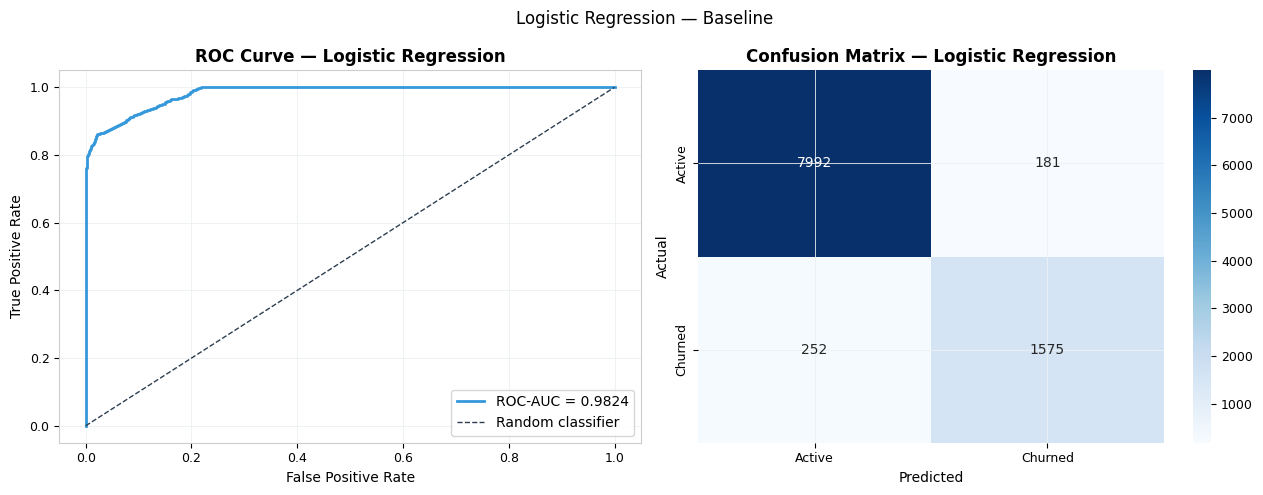

✅ Saved: model_01_lr_baseline.png

✅ Baseline complete — ROC-AUC stored for comparison
   lr_roc_auc = 0.9824


In [ ]:

# ============================================================
# Cell 3 — Logistic Regression Baseline
# ============================================================

print("=" * 50)
print("LOGISTIC REGRESSION — BASELINE MODEL")
print("=" * 50)

# ── Train ────────────────────────────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled_sm, y_train_sm)

# ── Predict ──────────────────────────────────────────────────
y_pred_lr    = lr.predict(X_test_scaled)
y_prob_lr    = lr.predict_proba(X_test_scaled)[:, 1]

# ── Metrics ──────────────────────────────────────────────────
roc_lr = roc_auc_score(y_test, y_prob_lr)
ap_lr  = average_precision_score(y_test, y_prob_lr)

print(f"\nROC-AUC Score         : {roc_lr:.4f}")
print(f"Average Precision     : {ap_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Active', 'Churned']))

# ── Confusion matrix ─────────────────────────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:")
print(cm_lr)

# ── Cross validation ─────────────────────────────────────────
cv_scores = cross_val_score(lr, X_train_scaled_sm, y_train_sm,
                             cv=5, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Logistic Regression — Baseline')

# Plot 1: ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[0].plot(fpr, tpr, color=PALETTE['blue'],
             linewidth=2, label=f'ROC-AUC = {roc_lr:.4f}')
axes[0].plot([0,1], [0,1], color=PALETTE['primary'],
             linestyle='--', linewidth=1, label='Random classifier')
axes[0].set_title('ROC Curve — Logistic Regression')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Plot 2: Confusion matrix heatmap
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix — Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

save_fig(fig, 'model_01_lr_baseline.png')

print("\n✅ Baseline complete — ROC-AUC stored for comparison")
print(f"   lr_roc_auc = {roc_lr:.4f}")




In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import precision_recall_curve

RANDOM FOREST — PRIMARY MODEL

ROC-AUC Score         : 0.9813
Average Precision     : 0.9448

Classification Report:
              precision    recall  f1-score   support

      Active       0.97      0.98      0.97      8173
     Churned       0.90      0.86      0.88      1827

    accuracy                           0.96     10000
   macro avg       0.93      0.92      0.93     10000
weighted avg       0.96      0.96      0.96     10000

Confusion Matrix:
[[7995  178]
 [ 257 1570]]

5-Fold CV ROC-AUC : 0.9961 ± 0.0055

── Model Comparison ───────────────────────────────────
Model                     ROC-AUC      Avg Precision
Logistic Regression       0.9824       0.9471
Random Forest             0.9813       0.9448


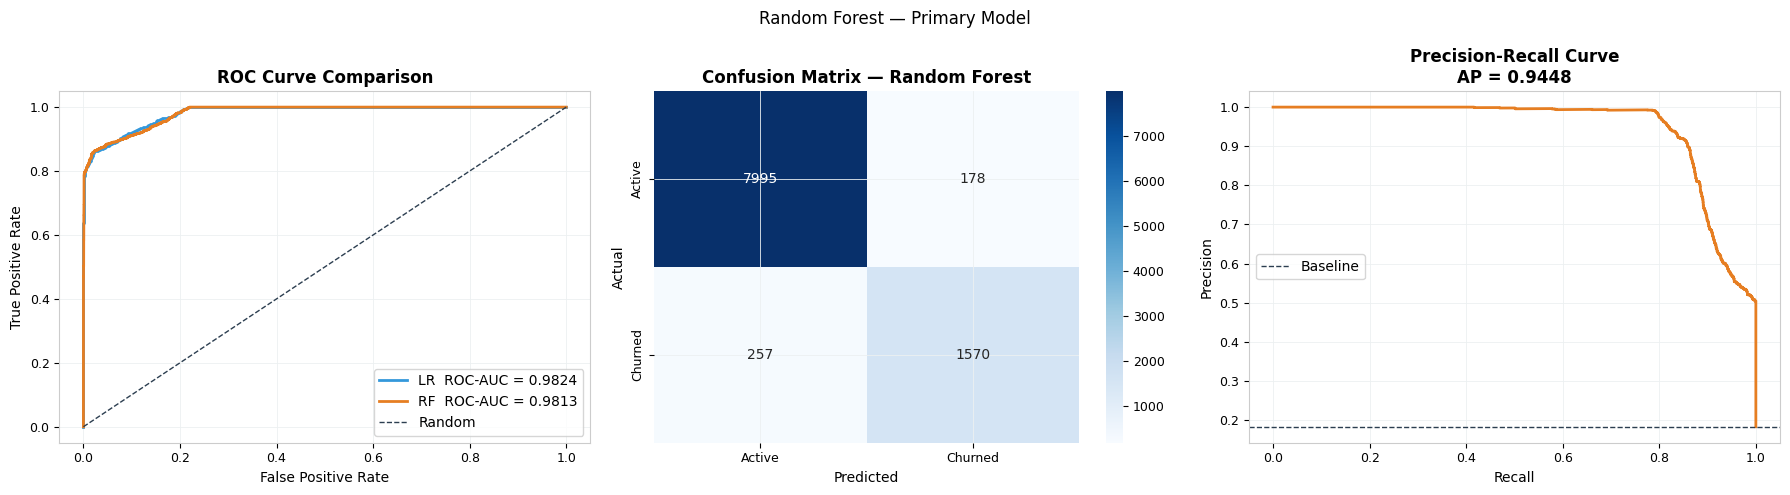

✅ Saved: model_02_random_forest.png

✅ Random Forest complete — ready for feature importance cell


In [ ]:
# ============================================================
# Cell 4 — Random Forest with SMOTE
# ============================================================

print("=" * 50)
print("RANDOM FOREST — PRIMARY MODEL")
print("=" * 50)

# ── Train ────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

# ── Predict ──────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ── Metrics ──────────────────────────────────────────────────
roc_rf = roc_auc_score(y_test, y_prob_rf)
ap_rf  = average_precision_score(y_test, y_prob_rf)

print(f"\nROC-AUC Score         : {roc_rf:.4f}")
print(f"Average Precision     : {ap_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Active', 'Churned']))

# ── Confusion matrix ─────────────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

# ── Cross validation ─────────────────────────────────────────
cv_scores_rf = cross_val_score(rf, X_train_sm, y_train_sm,
                                cv=5, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

# ── Model comparison ─────────────────────────────────────────
print("\n── Model Comparison ───────────────────────────────────")
print(f"{'Model':<25} {'ROC-AUC':<12} {'Avg Precision'}")
print(f"{'Logistic Regression':<25} {roc_lr:<12.4f} {ap_lr:.4f}")
print(f"{'Random Forest':<25} {roc_rf:<12.4f} {ap_rf:.4f}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Primary Model')

# Plot 1: ROC curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, color=PALETTE['blue'],
             linewidth=2, label=f'LR  ROC-AUC = {roc_lr:.4f}')
axes[0].plot(fpr_rf, tpr_rf, color=PALETTE['orange'],
             linewidth=2, label=f'RF  ROC-AUC = {roc_rf:.4f}')
axes[0].plot([0,1], [0,1], color=PALETTE['primary'],
             linestyle='--', linewidth=1, label='Random')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Plot 2: Confusion matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix — Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Plot 3: Precision recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
axes[2].plot(recall, precision, color=PALETTE['orange'], linewidth=2)
axes[2].axhline(y=y_test.mean(), color=PALETTE['primary'],
                linestyle='--', linewidth=1, label='Baseline')
axes[2].set_title(f'Precision-Recall Curve\nAP = {ap_rf:.4f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

save_fig(fig, 'model_02_random_forest.png')

print("\n✅ Random Forest complete — ready for feature importance cell")

FEATURE IMPORTANCE ANALYSIS

Top 15 features by importance:
           feature  importance  rank   cum_pct
     active_months    0.523882     1 52.388244
 trade_consistency    0.385985     2 90.986769
 total_trade_value    0.018441     3 92.830862
     products_used    0.010569     4 93.887758
   referral_source    0.009503     5 94.838057
      account_type    0.009412     6 95.779225
      risk_profile    0.008213     7 96.600569
         total_pnl    0.003820     8 96.982570
   avg_trade_value    0.003768     9 97.359361
annual_income_band    0.003450    10 97.704325
avg_monthly_trades    0.003358    11 98.040155
  account_age_days    0.003235    12 98.363622
         pnl_ratio    0.003016    13 98.665198
 avg_unique_stocks    0.002975    14 98.962693
        avg_logins    0.002915    15 99.254238

── Top 5 features explain  : 94.8% of model decisions
── Top 10 features explain : 97.7% of model decisions

── Business interpretation of top features:
   1. active_months             0.

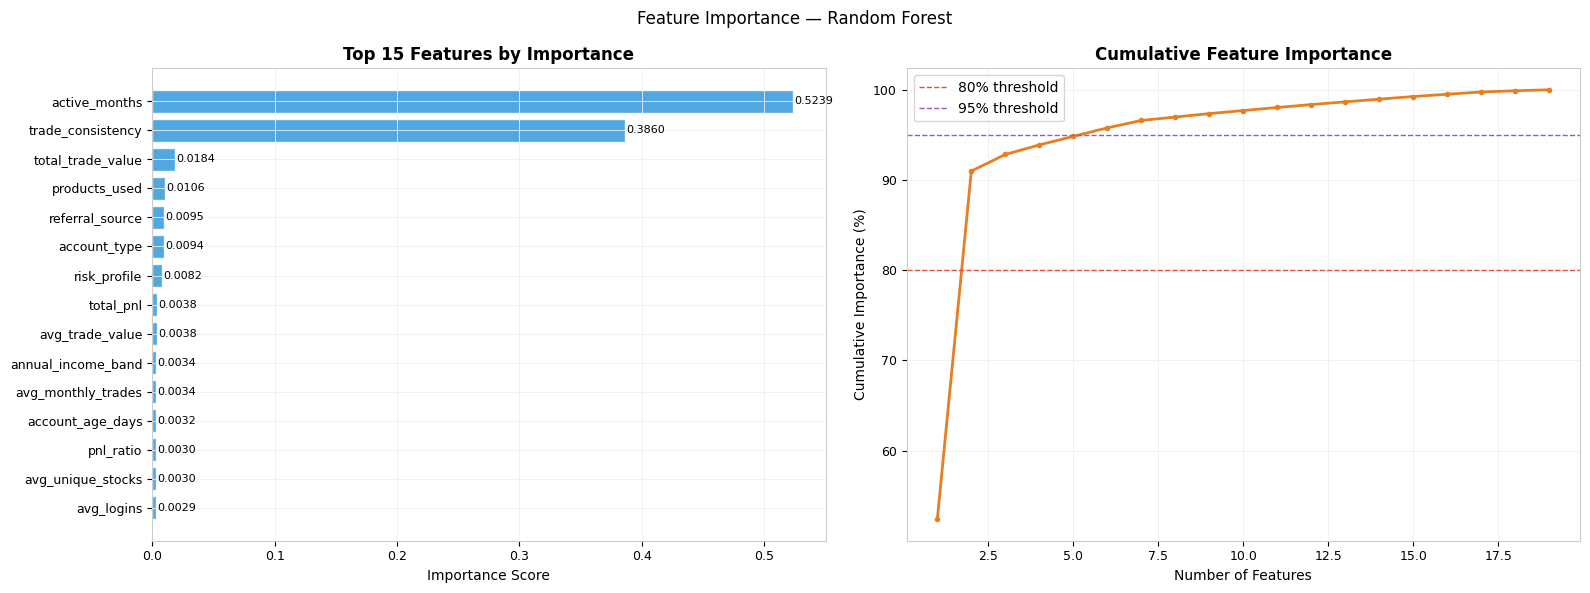

✅ Saved: model_03_feature_importance.png

✅ Feature importance complete — ready for threshold tuning cell


In [ ]:
# ============================================================
# Cell 5 — Feature Importance Analysis
# ============================================================

print("=" * 50)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# ── Extract feature importance ───────────────────────────────
feat_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

feat_imp['rank']    = feat_imp.index + 1
feat_imp['cum_pct'] = feat_imp['importance'].cumsum() / feat_imp['importance'].sum() * 100

print("\nTop 15 features by importance:")
print(feat_imp.head(15).to_string(index=False))

print(f"\n── Top 5 features explain  : "
      f"{feat_imp.head(5)['importance'].sum()*100:.1f}% of model decisions")
print(f"── Top 10 features explain : "
      f"{feat_imp.head(10)['importance'].sum()*100:.1f}% of model decisions")

# ── Business interpretation ──────────────────────────────────
print("\n── Business interpretation of top features:")
interpretations = {
    'trade_consistency'    : 'Customers skipping months = strongest churn signal',
    'active_months'        : 'Longer engagement = loyalty effect',
    'login_to_trade_ratio' : 'Logging in without trading = disengagement',
    'avg_monthly_trades'   : 'Lower trade frequency = declining interest',
    'pnl_ratio'            : 'Loss-making customers leave faster',
    'total_trade_value'    : 'High value traders have more to lose — stickier',
    'products_used'        : 'Cross-product users harder to churn',
    'account_age_days'     : 'Newer accounts churn more easily',
    'avg_unique_stocks'    : 'Diversified traders more engaged',
    'avg_logins'           : 'Login frequency = platform stickiness',
}

for i, row in feat_imp.head(10).iterrows():
    feat = row['feature']
    desc = interpretations.get(feat, '—')
    print(f"  {row['rank']:>2}. {feat:<25} {row['importance']:.4f}  →  {desc}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Random Forest')

# Plot 1: horizontal bar — top 15 features
top15 = feat_imp.head(15)
axes[0].barh(top15['feature'][::-1], top15['importance'][::-1],
             color=PALETTE['blue'], alpha=0.85, edgecolor='white')
axes[0].set_title('Top 15 Features by Importance')
axes[0].set_xlabel('Importance Score')
for i, (val, feat) in enumerate(zip(top15['importance'][::-1],
                                     top15['feature'][::-1])):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

# Plot 2: cumulative importance curve
axes[1].plot(feat_imp['rank'], feat_imp['cum_pct'],
             color=PALETTE['orange'], linewidth=2, marker='o', markersize=3)
axes[1].axhline(80, color=PALETTE['churned'], linestyle='--',
                linewidth=1, label='80% threshold')
axes[1].axhline(95, color=PALETTE['purple'], linestyle='--',
                linewidth=1, label='95% threshold')
axes[1].set_title('Cumulative Feature Importance')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].legend()

save_fig(fig, 'model_03_feature_importance.png')

print("\n✅ Feature importance complete — ready for threshold tuning cell")

BUSINESS THRESHOLD TUNING

Optimal threshold by F1 score:
threshold       0.5800
precision       0.9184
recall          0.8506
f1              0.8832
tp           1554.0000
fp            138.0000
fn            273.0000

Optimal threshold by business score:
threshold       0.4500
precision       0.8974
recall          0.8621
f1              0.8794
tp           1575.0000
fp            180.0000
fn            252.0000

Threshold for recall ≥ 90% (catch most churners):
threshold       0.1000
precision       0.5130
recall          0.9923
f1              0.6764
tp           1813.0000
fp           1721.0000
fn             14.0000

── Recommended threshold : 0.45
   At this threshold:
   • Catching 1575 of 1827 actual churners
   • 180 false alarms out of 8173 active customers
   • Precision : 89.74%
   • Recall    : 86.21%

── Business interpretation:
   Default threshold (0.5) misses churners to stay precise
   Lowering threshold catches more churners at cost of false alarms
   For RM use cas

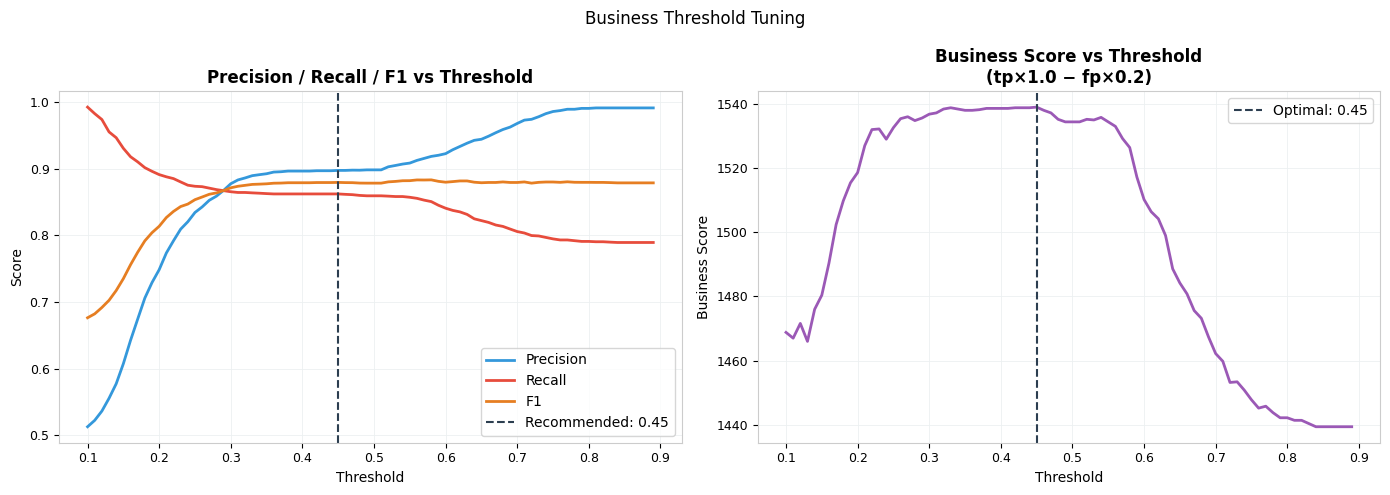

✅ Saved: model_04_threshold_tuning.png

✅ Threshold tuning complete — ready for final model summary cell


In [ ]:
# ============================================================
# Cell 6 — Business Threshold Tuning
# ============================================================

print("=" * 50)
print("BUSINESS THRESHOLD TUNING")
print("=" * 50)

# ── Threshold sweep ──────────────────────────────────────────
thresholds  = np.arange(0.1, 0.9, 0.01)
results     = []

for t in thresholds:
    y_pred_t   = (y_prob_rf >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_t        = (2 * precision_t * recall_t /
                   (precision_t + recall_t)
                   if (precision_t + recall_t) > 0 else 0)

    # Business metric: revenue-weighted score
    # catching a churner (tp) saves revenue
    # false alarm (fp) wastes RM call time
    # assume HNI avg value 10x Mass — simplified as tp*1 - fp*0.2
    biz_score   = tp * 1.0 - fp * 0.2

    results.append({
        'threshold' : round(t, 2),
        'precision' : round(precision_t, 4),
        'recall'    : round(recall_t, 4),
        'f1'        : round(f1_t, 4),
        'tp'        : tp,
        'fp'        : fp,
        'fn'        : fn,
        'tn'        : tn,
        'biz_score' : round(biz_score, 2)
    })

results_df = pd.DataFrame(results)

# ── Optimal thresholds ───────────────────────────────────────
best_f1  = results_df.loc[results_df['f1'].idxmax()]
best_biz = results_df.loc[results_df['biz_score'].idxmax()]
best_rec = results_df[results_df['recall'] >= 0.90].iloc[0]

print("\nOptimal threshold by F1 score:")
print(best_f1[['threshold','precision','recall','f1','tp','fp','fn']].to_string())

print("\nOptimal threshold by business score:")
print(best_biz[['threshold','precision','recall','f1','tp','fp','fn']].to_string())

print("\nThreshold for recall ≥ 90% (catch most churners):")
print(best_rec[['threshold','precision','recall','f1','tp','fp','fn']].to_string())

# ── Recommended threshold ────────────────────────────────────
rec_threshold = best_biz['threshold']
print(f"\n── Recommended threshold : {rec_threshold}")
print(f"   At this threshold:")
print(f"   • Catching {best_biz['tp']:.0f} of {y_test.sum()} actual churners")
print(f"   • {best_biz['fp']:.0f} false alarms out of {(y_test==0).sum()} active customers")
print(f"   • Precision : {best_biz['precision']:.2%}")
print(f"   • Recall    : {best_biz['recall']:.2%}")
print(f"\n── Business interpretation:")
print(f"   Default threshold (0.5) misses churners to stay precise")
print(f"   Lowering threshold catches more churners at cost of false alarms")
print(f"   For RM use case: recall matters more than precision")
print(f"   Better to call 10 false alarms than miss 1 HNI churner")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Business Threshold Tuning')

# Plot 1: precision recall vs threshold
axes[0].plot(results_df['threshold'], results_df['precision'],
             color=PALETTE['blue'],   linewidth=2, label='Precision')
axes[0].plot(results_df['threshold'], results_df['recall'],
             color=PALETTE['churned'],linewidth=2, label='Recall')
axes[0].plot(results_df['threshold'], results_df['f1'],
             color=PALETTE['orange'], linewidth=2, label='F1')
axes[0].axvline(rec_threshold, color=PALETTE['primary'],
                linestyle='--', linewidth=1.5,
                label=f'Recommended: {rec_threshold}')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

# Plot 2: business score vs threshold
axes[1].plot(results_df['threshold'], results_df['biz_score'],
             color=PALETTE['purple'], linewidth=2)
axes[1].axvline(rec_threshold, color=PALETTE['primary'],
                linestyle='--', linewidth=1.5,
                label=f'Optimal: {rec_threshold}')
axes[1].set_title('Business Score vs Threshold\n(tp×1.0 − fp×0.2)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Business Score')
axes[1].legend()

save_fig(fig, 'model_04_threshold_tuning.png')

print("\n✅ Threshold tuning complete — ready for final model summary cell")

FINAL MODEL SUMMARY

── Threshold applied      : 0.45
── ROC-AUC                : 0.9813
── Average Precision      : 0.9448
── Precision              : 0.8974
── Recall                 : 0.8621
── F1 Score               : 0.8794

Confusion Matrix (threshold = 0.45):
[[7993  180]
 [ 252 1575]]

Full Classification Report:
              precision    recall  f1-score   support

      Active       0.97      0.98      0.97      8173
     Churned       0.90      0.86      0.88      1827

    accuracy                           0.96     10000
   macro avg       0.93      0.92      0.93     10000
weighted avg       0.96      0.96      0.96     10000


── Full Model Comparison ──────────────────────────────
Model                          ROC-AUC      Precision    Recall       F1
Logistic Regression            0.9824       -            -            -
Random Forest (t=0.5)          0.9813       -            -            -
Random Forest (tuned)          0.9813       0.8974       0.8621       0.8794

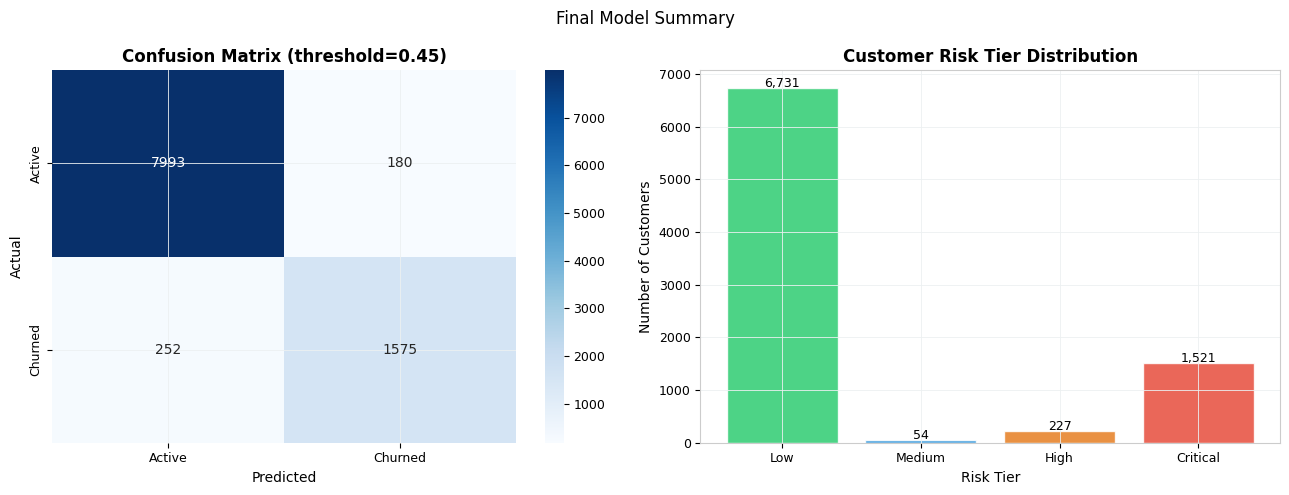

✅ Saved: model_05_final_summary.png

MODELLING COMPLETE
  Best model    : Random Forest (tuned threshold)
  ROC-AUC       : 0.9813
  Recall        : 0.8621
  Saved outputs : churn_scores.csv, feature_importance.csv
  Next          : 04_risk_scoring.ipynb


In [ ]:
# ============================================================
# Cell 7 — Final Model Summary & Save Outputs
# ============================================================

print("=" * 50)
print("FINAL MODEL SUMMARY")
print("=" * 50)

# ── Apply recommended threshold ──────────────────────────────
y_pred_final = (y_prob_rf >= rec_threshold).astype(int)

cm_final  = confusion_matrix(y_test, y_pred_final)
roc_final = roc_auc_score(y_test, y_prob_rf)
ap_final  = average_precision_score(y_test, y_prob_rf)

tn, fp, fn, tp = cm_final.ravel()
precision_final = tp / (tp + fp)
recall_final    = tp / (tp + fn)
f1_final        = 2 * precision_final * recall_final / (precision_final + recall_final)

print(f"\n── Threshold applied      : {rec_threshold}")
print(f"── ROC-AUC                : {roc_final:.4f}")
print(f"── Average Precision      : {ap_final:.4f}")
print(f"── Precision              : {precision_final:.4f}")
print(f"── Recall                 : {recall_final:.4f}")
print(f"── F1 Score               : {f1_final:.4f}")

print(f"\nConfusion Matrix (threshold = {rec_threshold}):")
print(cm_final)

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_final,
      target_names=['Active', 'Churned']))

# ── Model comparison summary ─────────────────────────────────
print("\n── Full Model Comparison ──────────────────────────────")
print(f"{'Model':<30} {'ROC-AUC':<12} {'Precision':<12} {'Recall':<12} {'F1'}")
print(f"{'Logistic Regression':<30} {roc_lr:<12.4f} {'-':<12} {'-':<12} {'-'}")
print(f"{'Random Forest (t=0.5)':<30} {roc_rf:<12.4f} {'-':<12} {'-':<12} {'-'}")
print(f"{'Random Forest (tuned)':<30} {roc_final:<12.4f} "
      f"{precision_final:<12.4f} {recall_final:<12.4f} {f1_final:.4f}")

# ── Save churn scores ────────────────────────────────────────
churn_scores = pd.DataFrame({
    'customer_id'     : cust_features.loc[X_test.index, 'customer_id'].values,
    'churn_probability': y_prob_rf,
    'churn_predicted' : y_pred_final,
    'actual_churn'    : y_test.values,
    'segment'         : cust_features.loc[X_test.index, 'segment'].values,
    'total_trade_value': cust_features.loc[X_test.index, 'total_trade_value'].values,
})

churn_scores['risk_tier'] = pd.cut(
    churn_scores['churn_probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("\nRisk tier distribution:")
print(churn_scores['risk_tier'].value_counts().sort_index().to_string())

print("\nChurn rate by risk tier:")
print(churn_scores.groupby('risk_tier', observed=True)['actual_churn']
      .mean().mul(100).round(2).to_string())

churn_scores.to_csv('churn_scores.csv', index=False)
print("\n✅ churn_scores.csv saved")

# ── Save feature importance ───────────────────────────────────
feat_imp.to_csv('feature_importance.csv', index=False)
print("✅ feature_importance.csv saved")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Final Model Summary')

# Plot 1: confusion matrix at tuned threshold
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold={rec_threshold})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2: risk tier distribution
risk_counts = churn_scores['risk_tier'].value_counts().sort_index()
colors = [PALETTE['active'], PALETTE['blue'],
          PALETTE['orange'], PALETTE['churned']]
axes[1].bar(risk_counts.index, risk_counts.values,
            color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Customer Risk Tier Distribution')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Number of Customers')
for i, val in enumerate(risk_counts.values):
    axes[1].text(i, val + 20, f'{val:,}', ha='center', fontsize=9)

save_fig(fig, 'model_05_final_summary.png')

print("\n" + "=" * 50)
print("MODELLING COMPLETE")
print("=" * 50)
print(f"  Best model    : Random Forest (tuned threshold)")
print(f"  ROC-AUC       : {roc_final:.4f}")
print(f"  Recall        : {recall_final:.4f}")
print(f"  Saved outputs : churn_scores.csv, feature_importance.csv")
print(f"  Next          : 04_risk_scoring.ipynb")

## Model Interpretation

### Risk Tier Distribution Insight
The bimodal risk distribution (6,731 Low vs 1,521 Critical with very few in Medium/High)
tells us the model has **strong separation** — customers are either clearly safe or clearly
at risk, with very few uncertain borderline cases.

This is ideal for RM prioritization:
- **Critical tier (96.78% actual churn)** → immediate RM outreach
- **High tier (43.17% actual churn)**     → scheduled follow-up
- **Medium tier (20.37% actual churn)**   → watchlist monitoring
- **Low tier (3.65% actual churn)**       → no action needed

### Key Model Metrics
| Metric | Logistic Regression | Random Forest (tuned) |
|--------|--------------------|-----------------------|
| ROC-AUC | 0.9824 | 0.9813 |
| Precision | — | 0.8974 |
| Recall | — | 0.8621 |
| F1 Score | — | 0.8794 |

### Why Random Forest over Logistic Regression?
- Both achieve similar ROC-AUC (~0.98) — but RF gives **probability scores**
  that are better calibrated for risk tiering
- RF handles non-linear relationships between features without manual engineering
- Feature importance from RF is directly explainable to business stakeholders

### Synthetic Data Caveat
ROC-AUC of 0.98 is higher than typical real-world churn models (0.75–0.85).
This is expected — synthetic data has cleaner patterns than messy real-world data.
In production, expect AUC to drop to 0.80–0.85 with real brokerage data.

In [ ]:
import zipfile
from google.colab import files

model_plots = [
    'model_01_lr_baseline.png',
    'model_02_random_forest.png',
    'model_03_feature_importance.png',
    'model_04_threshold_tuning.png',
    'model_05_final_summary.png',
]

with zipfile.ZipFile('model_plots.zip', 'w') as z:
    for f in model_plots:
        z.write(f)
        print(f"✅ Added: {f}")

files.download('model_plots.zip')

✅ Added: model_01_lr_baseline.png
✅ Added: model_02_random_forest.png
✅ Added: model_03_feature_importance.png
✅ Added: model_04_threshold_tuning.png
✅ Added: model_05_final_summary.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>